# **Child Well-being - Minimum Dominant Set visualization**<br/>
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**  

In [37]:
import sys; sys.path.insert(0, "..")
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [38]:
path = f"../data/050_posets_macro_dimensions_3_level.pkl"
with open(path, "rb") as f:
    data = pickle.load(f)

In [39]:
def get_mds_elements(poset_dict: dict) -> set:
    """
    Extract the Minimum Dominant Set (MDS) from a poset result.

    The MDS consists of all maximal elements — those not dominated
    by any other element in the certain dominance relation.
    """
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict["elements"])
    G.add_edges_from(poset_dict["dom_certain"])

    # Maximal elements: nodes with in-degree 0 in the dominance graph
    # (no one dominates them)
    maximals = {n for n, deg in G.in_degree() if deg == 0}
    return maximals

def shorten_country(label: str, sep: str = "_") -> str:
    """'SWE_2015' → 'SWE'"""
    return label.split(sep)[0] if sep in label else label

In [40]:
mds_2015 = get_mds_elements(data["ind_2015"])
mds_2018 = get_mds_elements(data["ind_2018"])

clean_2015 = {shorten_country(c) for c in mds_2015}
clean_2018 = {shorten_country(c) for c in mds_2018}

stable = clean_2015 & clean_2018
exited = clean_2015 - clean_2018
entered = clean_2018 - clean_2015
jaccard = len(stable) / len(clean_2015 | clean_2018) if clean_2015 | clean_2018 else 0

print("=" * 55)
print("  MDS LEADERSHIP STABILITY ANALYSIS")
print("=" * 55)
print(f"  Jaccard Similarity: {jaccard:.2f}  (1.0 = identical, 0.0 = disjoint)")
print(f"  Stable leaders (both years):  {sorted(stable)}")
print(f"  Exited leadership in 2018:    {sorted(exited) if exited else 'None'}")
print(f"  New leaders in 2018:          {sorted(entered) if entered else 'None'}")
print()

  MDS LEADERSHIP STABILITY ANALYSIS
  Jaccard Similarity: 0.00  (1.0 = identical, 0.0 = disjoint)
  Stable leaders (both years):  []
  Exited leadership in 2018:    ['EST']
  New leaders in 2018:          ['ITA', 'LTU']



In [41]:
def draw_hasse_on_axis(
    ax,
    poset_dict: dict,
    title: str,
    font_size: int = 9,
    arrow_size: int = 15,
    layer_spacing: float = 8.0,
    color_mds: tuple = ("#FFECEC", "#FF7675", "#D63031"),
    color_dom: tuple = ("#F0F8FF", "#74B9FF", "#0984E3"),
    shorten_labels: bool = True,
    label_sep: str = "_",
):
    """
    Draw a Hasse diagram on a matplotlib Axes, highlighting MDS elements.

    Handles equivalence classes (nodes with identical dominance profiles)
    via graph condensation.

    Parameters
    ----------
    ax : matplotlib Axes
    poset_dict : dict
        Output of poset_from_polars().
    title : str
    color_mds : tuple of (bg, border, text) for MDS elements
    color_dom : tuple of (bg, border, text) for dominated elements
    shorten_labels : bool
        Shorten 'SWE_2015' → 'SWE' inside node boxes.
    """
    # Build dominance graph and condense equivalence classes
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict["elements"])
    G.add_edges_from(poset_dict["dom_certain"])
    C = nx.condensation(G)
    TR_C = nx.transitive_reduction(C)

    # Build Hasse graph on condensed nodes
    Hasse_G = nx.DiGraph()
    mapping = {}
    for n in C.nodes():
        members = sorted(C.nodes[n]["members"])
        if shorten_labels:
            display = [m.split(label_sep)[0] if label_sep in m else m for m in members]
        else:
            display = members
        label = "\n".join(display)
        mapping[n] = label
        Hasse_G.add_node(label, raw_members=members)

    for u, v in TR_C.edges():
        Hasse_G.add_edge(mapping[u], mapping[v])

    # MDS: source nodes in condensation (in-degree 0 = no one dominates them)
    mds_members = set()
    for n, deg in C.in_degree():
        if deg == 0:
            mds_members.update(C.nodes[n]["members"])

    # Layer assignment (longest-path from sources)
    layers = {node: 0 for node in Hasse_G.nodes()}
    sources = [n for n in Hasse_G.nodes() if Hasse_G.in_degree(n) == 0]
    for src in sources:
        for target, length in nx.single_source_shortest_path_length(Hasse_G, src).items():
            layers[target] = max(layers[target], length)

    # Group by layer
    layer_nodes = {}
    for node, layer in layers.items():
        layer_nodes.setdefault(layer, []).append(node)

    # Position: MDS on top, most connected nodes centered
    max_layer = max(layer_nodes.keys()) if layer_nodes else 0
    pos = {}
    for layer, nodes_in_layer in layer_nodes.items():
        y = max_layer - layer
        n_nodes = len(nodes_in_layer)
        nodes_in_layer.sort(key=lambda x: -Hasse_G.out_degree(x))
        for i, node in enumerate(nodes_in_layer):
            x = (i - (n_nodes - 1) / 2.0) * (layer_spacing / max(1, n_nodes))
            pos[node] = (x, y)

    # Draw edges
    if Hasse_G.edges():
        nx.draw_networkx_edges(
            Hasse_G, pos, ax=ax,
            edge_color="#BDC3C7",
            width=1.5,
            arrows=True,
            arrowsize=arrow_size,
            arrowstyle="-|>",
            node_size=3500,
            connectionstyle="arc3,rad=0.08",
        )

    # Draw nodes as text boxes
    for node in Hasse_G.nodes():
        raw = Hasse_G.nodes[node].get("raw_members", [])
        is_mds = any(m in mds_members for m in raw)
        bg, border, text_col = color_mds if is_mds else color_dom

        ax.text(
            pos[node][0], pos[node][1], node,
            ha="center", va="center",
            fontsize=font_size, fontweight="bold", color=text_col,
            bbox=dict(
                boxstyle="round,pad=0.6,rounding_size=0.4",
                facecolor=bg, edgecolor=border, linewidth=1.5,
            ),
        )

    ax.set_title(title, fontsize=14, fontweight="bold", color="#2C3E50", pad=15)
    ax.axis("off")


def plot_mds_grid(
    data: dict,
    titles: dict | None = None,
    suptitle: str = "MDS and Pareto Frontier Analysis (2015 vs 2018)",
    figsize: tuple = (22, 18),
    save_path: str | None = None,
    dpi: int = 200,
    **hasse_kwargs,
):
    """
    2×2 grid of Hasse diagrams with MDS highlighting.

    Parameters
    ----------
    data : dict
        Keys → poset_dict, e.g. {'ind_2015': ..., 'ind_2018': ..., ...}
    titles : dict, optional
        {key: display_title}. Auto-generated if None.
    """
    keys = sorted(data.keys())
    n = len(keys)
    ncols = min(n, 2)
    nrows = (n + ncols - 1) // ncols

    if titles is None:
        titles = {k: k.replace("_", " ").title() for k in keys}

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, facecolor="#F8F9FA",
    )
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, key in enumerate(keys):
        draw_hasse_on_axis(
            axes[i], data[key],
            title=titles.get(key, key),
            **hasse_kwargs,
        )

    # Hide unused axes
    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    # Legend
    patches = [
        mpatches.Patch(
            facecolor="#FFECEC", edgecolor="#FF7675",
            linewidth=2, label="MDS (Maximal classes)",
        ),
        mpatches.Patch(
            facecolor="#F0F8FF", edgecolor="#74B9FF",
            linewidth=2, label="Dominated elements",
        ),
    ]
    fig.legend(
        handles=patches, loc="lower center", ncol=2,
        fontsize=12, frameon=True, facecolor="white",
        edgecolor="#BDC3C7", borderpad=1,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.suptitle(
        suptitle, fontsize=18, fontweight="bold",
        color="#2C3E50", y=0.98,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, axes

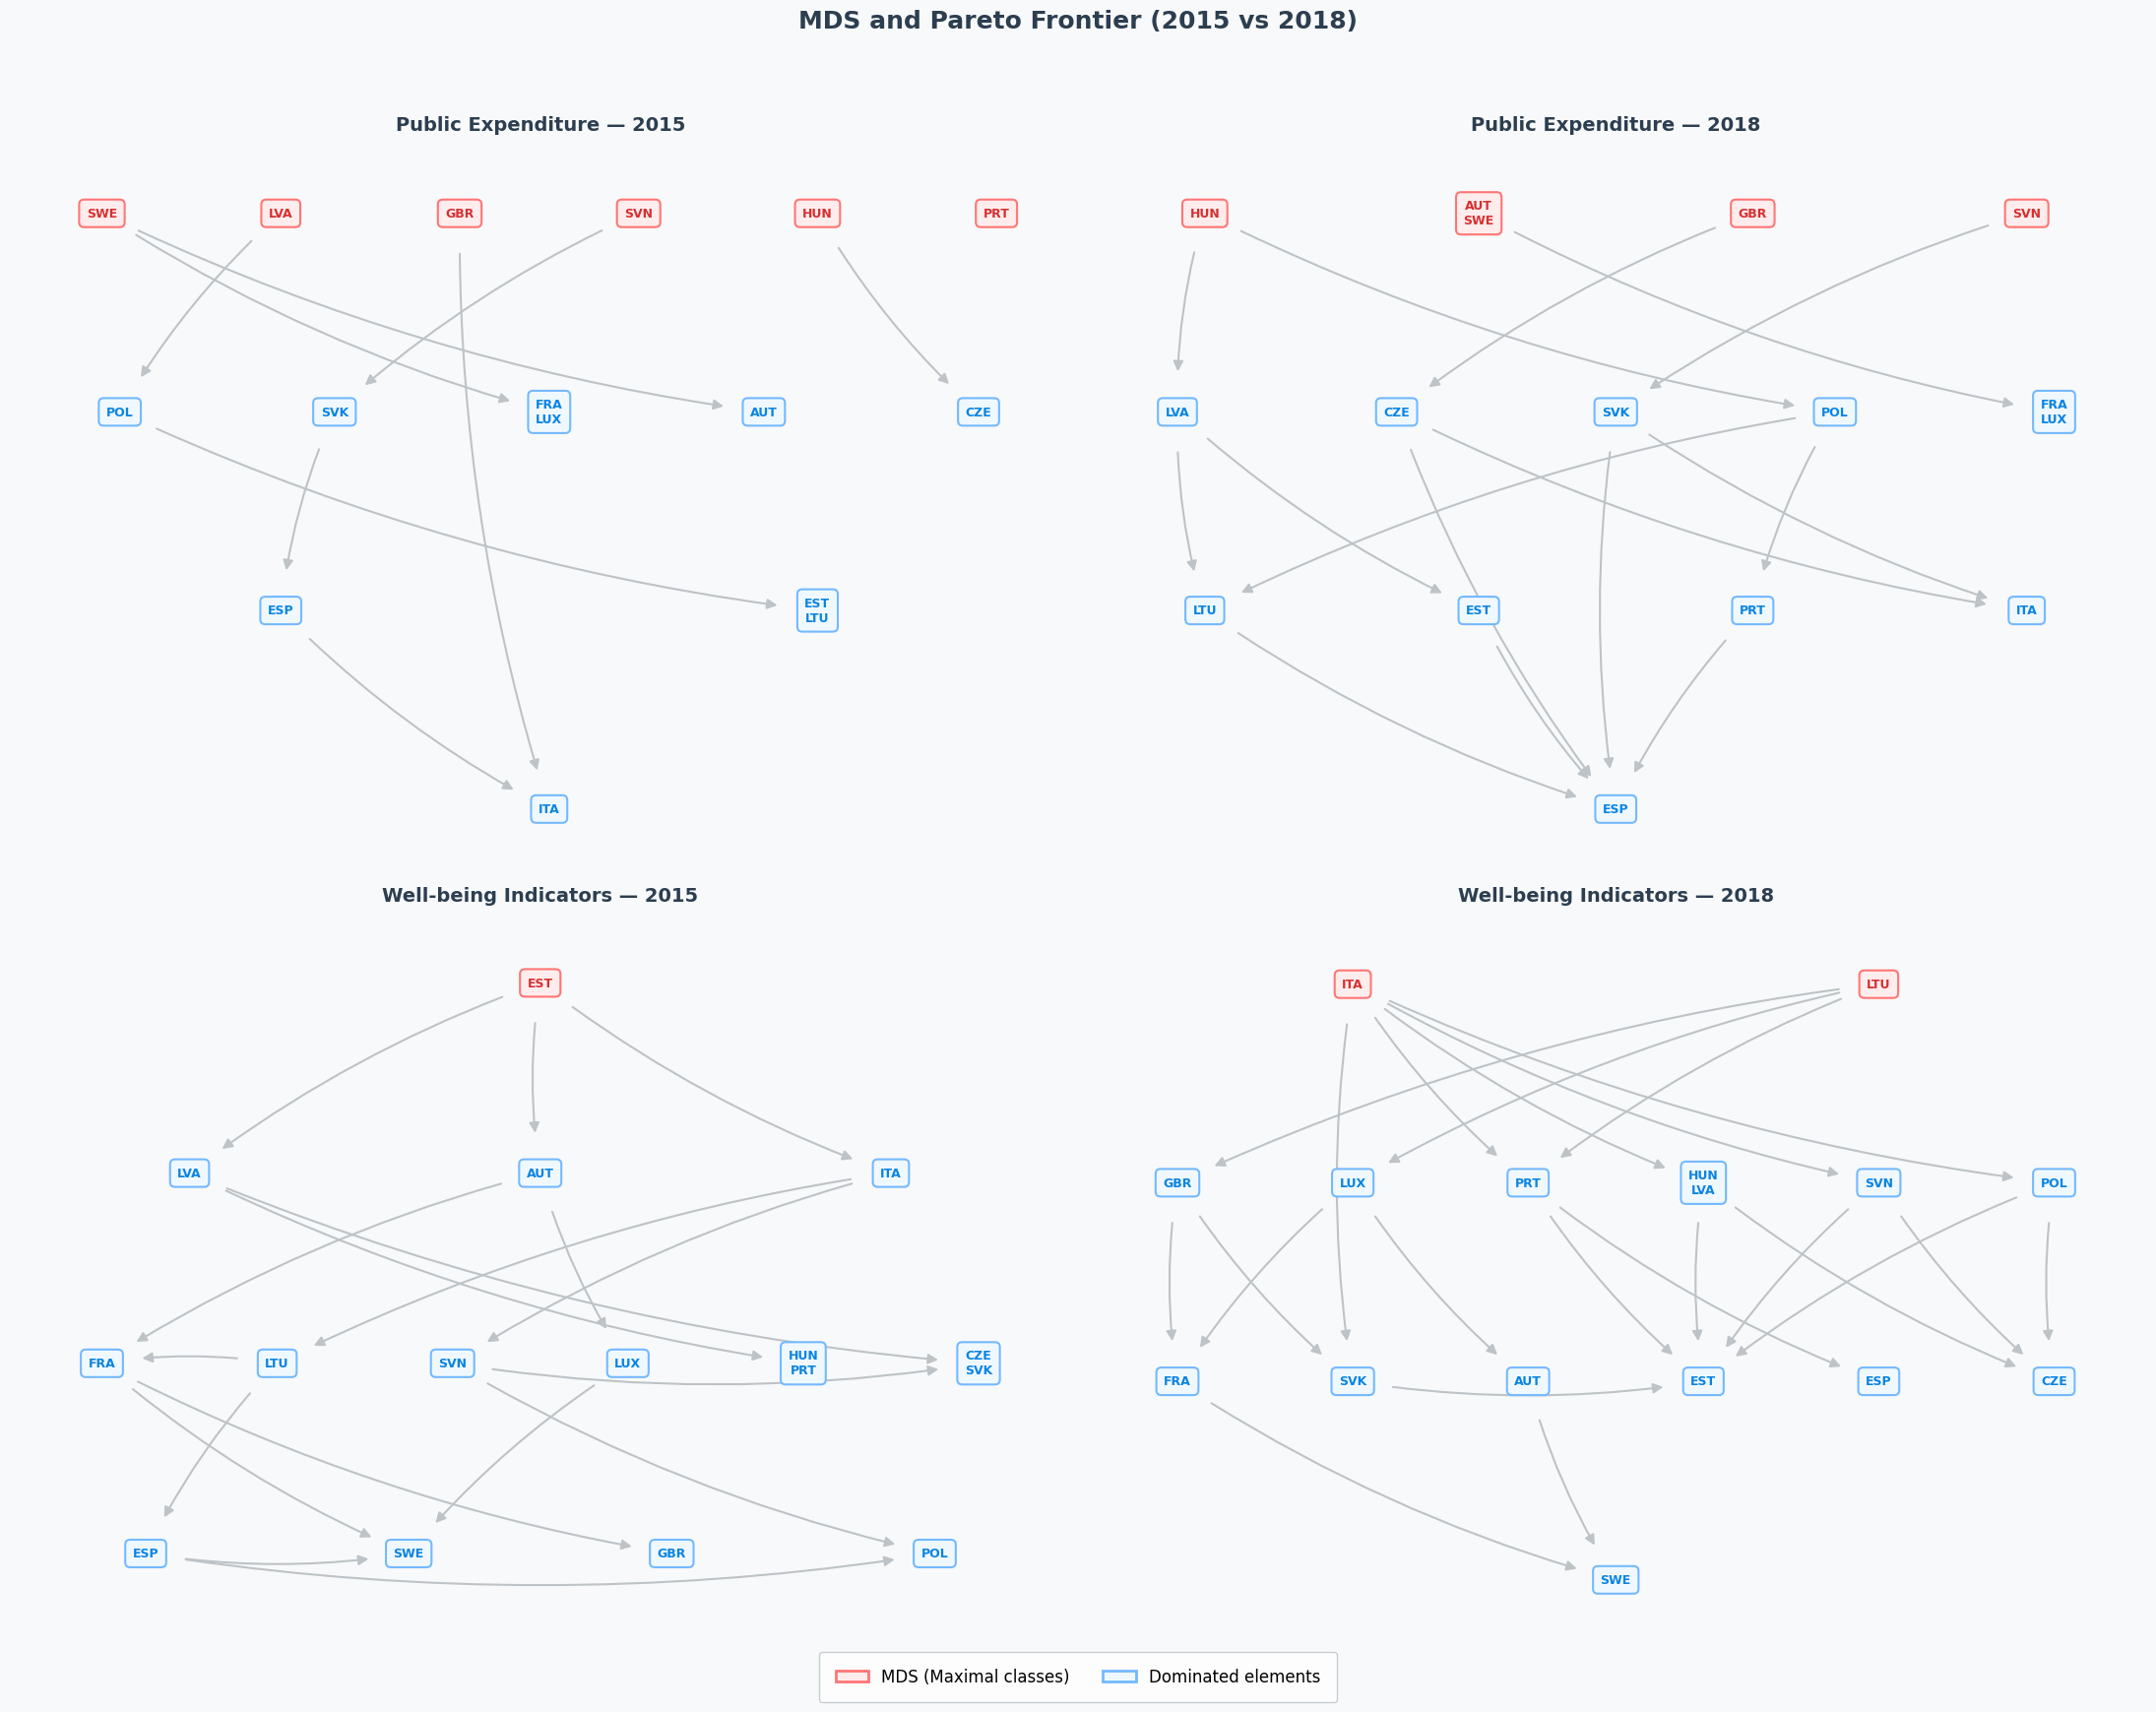

(<Figure size 2200x1800 with 4 Axes>,
 array([<Axes: title={'center': 'Public Expenditure — 2015'}>,
        <Axes: title={'center': 'Public Expenditure — 2018'}>,
        <Axes: title={'center': 'Well-being Indicators — 2015'}>,
        <Axes: title={'center': 'Well-being Indicators — 2018'}>],
       dtype=object))

In [42]:
plot_mds_grid(
    data,
    titles={
        "exp_2015": "Public Expenditure — 2015",
        "exp_2018": "Public Expenditure — 2018",
        "ind_2015": "Well-being Indicators — 2015",
        "ind_2018": "Well-being Indicators — 2018",
    },
    suptitle="MDS and Pareto Frontier (2015 vs 2018)",
    shorten_labels=True,
)

In [44]:
def analyze_bottleneck(
    poset_dict: dict,
    country_a: str,
    country_b: str,
    verbose: bool = True,
) -> dict:
    """
    Explain why country_a does NOT certainly dominate country_b.

    For certain dominance, a ≤ b requires hi[a,k] ≤ lo[b,k] for all k.
    A bottleneck is any indicator where hi[a,k] > lo[b,k].

    Parameters
    ----------
    poset_dict : dict
        Output of poset_from_polars().
    country_a, country_b : str
        Element labels (e.g. 'SWE_2018').
    verbose : bool
        Print detailed analysis.

    Returns
    -------
    dict with keys:
        'bottlenecks'   : list of dict — indicators blocking dominance
        'supports'      : list of dict — indicators where a dominates b
        'n_bottlenecks' : int
        'n_supports'    : int
        'dominates'     : bool — True if a certainly dominates b
    """
    intervals = poset_dict["intervals"]
    cols = poset_dict["indicator_cols"]

    if country_a not in intervals or country_b not in intervals:
        raise ValueError(
            f"Element not found. Available: {sorted(intervals.keys())}"
        )

    hi_a = intervals[country_a]["hi"]
    lo_a = intervals[country_a]["lo"]
    hi_b = intervals[country_b]["hi"]
    lo_b = intervals[country_b]["lo"]
    null_a = poset_dict["null_mask"][country_a]
    null_b = poset_dict["null_mask"][country_b]

    bottlenecks = []
    supports = []

    for i, col in enumerate(cols):
        gap = lo_b[i] - hi_a[i]  # positive = b certainly above a on this indicator

        entry = {
            "indicator": col,
            "a_lo": lo_a[i],
            "a_hi": hi_a[i],
            "b_lo": lo_b[i],
            "b_hi": hi_b[i],
            "gap": gap,
            "a_null": bool(null_a[i]),
            "b_null": bool(null_b[i]),
        }

        if hi_a[i] > lo_b[i]:
            # a's best case exceeds b's worst case → blocks certain dominance
            bottlenecks.append(entry)
        else:
            supports.append(entry)

    dominates = len(bottlenecks) == 0

    if verbose:
        a_short = country_a.split("_")[0]
        b_short = country_b.split("_")[0]

        if dominates:
            print(f"{a_short} certainly dominates {b_short} on all {len(cols)} indicators.")
        else:
            print(f"Why {a_short} does NOT certainly dominate {b_short}:")
            print(f"  {len(supports)} indicators support dominance, "
                  f"{len(bottlenecks)} block it.\n")

            print("  BOTTLENECKS (blocking dominance):")
            # Sort by gap (most blocking first)
            for b in sorted(bottlenecks, key=lambda x: x["gap"]):
                null_flag = ""
                if b["a_null"] or b["b_null"]:
                    null_flag = "  [null uncertainty]"
                print(f"    {b['indicator']:30s}  "
                      f"{a_short}=[{b['a_lo']:.1f}, {b['a_hi']:.1f}]  "
                      f"{b_short}=[{b['b_lo']:.1f}, {b['b_hi']:.1f}]  "
                      f"gap={b['gap']:+.1f}{null_flag}")

            if supports:
                print(f"\n  SUPPORTS (a ≤ b holds):")
                for s in sorted(supports, key=lambda x: -x["gap"]):
                    print(f"    {s['indicator']:30s}  "
                          f"{a_short}=[{s['a_lo']:.1f}, {s['a_hi']:.1f}]  "
                          f"{b_short}=[{s['b_lo']:.1f}, {s['b_hi']:.1f}]  "
                          f"gap={s['gap']:+.1f}")

    return {
        "bottlenecks": bottlenecks,
        "supports": supports,
        "n_bottlenecks": len(bottlenecks),
        "n_supports": len(supports),
        "dominates": dominates,
    }

In [45]:
# Single pair
result = analyze_bottleneck(data["ind_2018"], "SVN_2018", "LTU_2018")

# Compare multiple pairs
for a, b in [("SWE_2018", "LTU_2018"), ("SVN_2018", "LTU_2018"), ("GBR_2018", "ITA_2018")]:
    print(f"\n{'='*60}")
    analyze_bottleneck(data["ind_2018"], a, b)

Why SVN does NOT certainly dominate LTU:
  1 indicators support dominance, 3 block it.

  BOTTLENECKS (blocking dominance):
    health_prevention               SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0
    education_skills                SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0
    social_wellbeing                SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0

  SUPPORTS (a ≤ b holds):
    material_protection             SVN=[1.0, 1.0]  LTU=[2.0, 2.0]  gap=+1.0

Why SWE does NOT certainly dominate LTU:
  1 indicators support dominance, 3 block it.

  BOTTLENECKS (blocking dominance):
    health_prevention               SWE=[3.0, 3.0]  LTU=[1.0, 1.0]  gap=-2.0
    material_protection             SWE=[3.0, 3.0]  LTU=[2.0, 2.0]  gap=-1.0
    education_skills                SWE=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0

  SUPPORTS (a ≤ b holds):
    social_wellbeing                SWE=[1.0, 1.0]  LTU=[1.0, 1.0]  gap=+0.0

Why SVN does NOT certainly dominate LTU:
  1 indicators support dominance, 3 blo

In Posets (Partially Ordered Sets), if a node (Nation A) dominates another node (Nation B), it means that Nation A has equal or superior performance across all indicators compared to Nation B. The MDS (Minimum Dominating Set) tells us the minimum number of "leaders" required to cover (outperform or equal) all others.

# ind_2015 (MDS: 1) - The Absolute Leader
Estonia (EST_2015) covers the entire set on its own. This is a rare and very strong result. It means that Estonia, in that year and for that group of indicators, had a profile that was equal to or superior to all other 15 nations. There was no country with a combination of values that could "challenge" Estonia across the board.

# ind_2018 (MDS: 2) - Polarization
Here, two nations are required: Lithuania (LTU_2018) and Italy (ITA_2018). What does this mean? It means these two countries offer two different "models of excellence" that are incomparable to each other. Italy may be strong in certain indicators where Lithuania is weak, and vice versa. However, by combining them, any other European country in the dataset proves to be inferior (or equal) to at least one of the two.

# exp_2018 (MDS: 4) and exp_2015 (MDS: 6) - Diffuse Incomparability
In the "exp" scenarios, the situation becomes more complex. An MDS of 6 nations means there are no clear leaders. The countries' profiles are very "jagged": perhaps Sweden excels in indicator X but drops in Y, while Latvia does the opposite. There is a high degree of incomparability. The larger the MDS, the less the set of indicators is able to create a clear hierarchy among the nations.

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*